# POS Tagging, HMMs, and the Forward / Viterbi / Baum-Welch Algorithms

**A step-by-step educational notebook**

This notebook covers:
1. Introduction to Part-of-Speech (POS) Tagging
2. Word Classes & the Penn Treebank Tagset
3. Markov Chains for POS sequences
4. Hidden Markov Models (HMMs)
5. The Forward Algorithm (computing likelihood)
6. The Viterbi Algorithm (finding the best tag sequence)
7. The Backward Algorithm
8. Posterior Probabilities $\gamma_t(i)$
9. The Baum-Welch (EM) Algorithm for unsupervised learning
10. Summary & Comparison

---

In [1]:
# ── Global imports and settings ──────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display, HTML
import warnings, textwrap

# Try seaborn; fall back to plain matplotlib if unavailable
try:
    import seaborn as sns
    HAS_SNS = True
except ImportError:
    HAS_SNS = False

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 10,
})
print("All imports OK.")

All imports OK.


---
## 1. Introduction to POS Tagging

**Part-of-Speech (POS) tagging** is the task of assigning a grammatical category (noun, verb, adjective, etc.) to every word in a sentence.

**Why it matters:**
- Foundation for parsing, named-entity recognition, and information extraction
- Resolves syntactic ambiguity (e.g., *"book"* can be a **noun** or a **verb**)
- Improves downstream tasks like machine translation and text-to-speech

**Example:**

| The | cat | sat | on | the | mat |
|-----|-----|-----|----|-----|-----|
| DT  | NN  | VBD | IN | DT  | NN  |

**Ambiguity example:** the word *"book"*
- *"Read the **book**."* → NN (noun)
- *"Please **book** a flight."* → VB (verb)

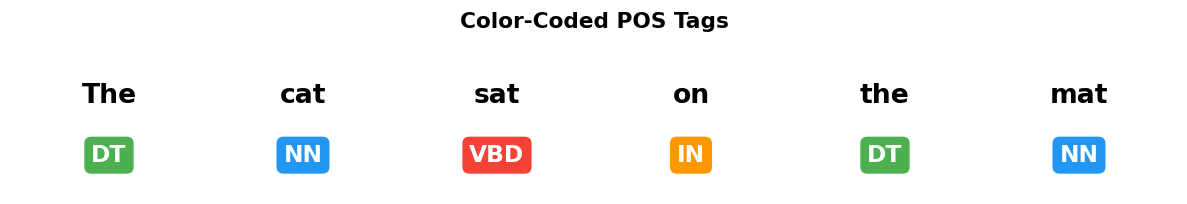

In [ ]:
# ── Visualization: color-coded tagged sentence ──────────────────────
tag_colors = {
    "DT": "#4CAF50",   # green
    "NN": "#2196F3",   # blue
    "VBD": "#F44336",  # red
    "IN": "#FF9800",   # orange
    "JJ": "#9C27B0",   # purple
    "VB": "#F44336",   # red (verb)
}

words = ["The", "cat", "sat", "on", "the", "mat"]
tags  = ["DT",  "NN",  "VBD", "IN", "DT",  "NN"]

fig, ax = plt.subplots(figsize=(10, 1.8))
ax.set_xlim(0, len(words))
ax.set_ylim(0, 2)
ax.axis("off")
ax.set_title("Color-Coded POS Tags", fontweight="bold", pad=10)

for i, (w, t) in enumerate(zip(words, tags)):
    c = tag_colors.get(t, "#555")
    ax.text(i + 0.5, 1.3, w, ha="center", va="center", fontsize=16, fontweight="bold")
    ax.text(i + 0.5, 0.5, t, ha="center", va="center", fontsize=14,
            color="white", fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", fc=c, ec="none"))

plt.tight_layout()
plt.show()

---
## 2. Word Classes & the Penn Treebank Tagset

POS tags fall into two broad groups:

### Open classes (productive — new words added regularly)
- **Nouns (NN, NNS, NNP, NNPS):** objects, people, places
- **Verbs (VB, VBD, VBG, VBN, VBP, VBZ):** actions, states
- **Adjectives (JJ, JJR, JJS):** modify nouns
- **Adverbs (RB, RBR, RBS):** modify verbs/adjectives

### Closed classes (fixed membership)
- **Determiners (DT):** the, a, an
- **Prepositions (IN):** on, in, at, to
- **Conjunctions (CC):** and, but, or
- **Pronouns (PRP, PRP$):** he, she, it
- **Modals (MD):** can, will, should

### Common Penn Treebank Tags

| Tag | Description | Example |
|-----|-------------|---------|
| DT | Determiner | the, a |
| NN | Noun, singular | cat, book |
| NNS | Noun, plural | cats, books |
| NNP | Proper noun | London |
| VB | Verb, base form | run, book |
| VBD | Verb, past tense | ran, booked |
| VBG | Verb, gerund | running |
| VBN | Verb, past participle | eaten |
| JJ | Adjective | big, red |
| RB | Adverb | quickly |
| IN | Preposition/sub-conj | on, in, that |
| CC | Coordinating conj | and, but |
| PRP | Personal pronoun | he, she |
| MD | Modal | can, will |
| TO | "to" | to |
| . | Punctuation | . ! ? |

---
## 3. Markov Chains for POS Tag Sequences

A **first-order Markov chain** assumes that the probability of the current tag depends only on the previous tag:

$$P(t_i \mid t_1, t_2, \ldots, t_{i-1}) \approx P(t_i \mid t_{i-1})$$

### Training Corpus

We will use three tagged sentences:

1. The/DT cat/NN sat/VBD on/IN the/DT mat/NN
2. The/DT dog/NN ran/VBD to/IN the/DT park/NN
3. A/DT big/JJ cat/NN sat/VBD on/IN a/DT mat/NN

**Tags in our corpus:** DT, NN, VBD, IN, JJ

Let's derive the **transition count matrix** and **transition probability matrix** $A$.

In [ ]:
# ── Training corpus ──────────────────────────────────────────────────
corpus = [
    [("The","DT"),("cat","NN"),("sat","VBD"),("on","IN"),("the","DT"),("mat","NN")],
    [("The","DT"),("dog","NN"),("ran","VBD"),("to","IN"),("the","DT"),("park","NN")],
    [("A","DT"),("big","JJ"),("cat","NN"),("sat","VBD"),("on","IN"),("a","DT"),("mat","NN")],
]

# Ordered tag set
tag_list = ["DT", "NN", "VBD", "IN", "JJ"]
tag2idx  = {t: i for i, t in enumerate(tag_list)}
N_tags   = len(tag_list)

# ── Count transitions ───────────────────────────────────────────────
trans_counts = np.zeros((N_tags, N_tags), dtype=int)
start_counts = np.zeros(N_tags, dtype=int)

for sent in corpus:
    start_counts[tag2idx[sent[0][1]]] += 1          # first tag
    for k in range(len(sent) - 1):
        i = tag2idx[sent[k][1]]
        j = tag2idx[sent[k + 1][1]]
        trans_counts[i, j] += 1

print("Transition COUNT matrix (rows = from, cols = to):")
df_counts = pd.DataFrame(trans_counts, index=tag_list, columns=tag_list)
display(df_counts)

Transition COUNT matrix (rows = from, cols = to):


,DT,NN,VBD,IN,JJ
DT,0,5,0,0,1
NN,0,0,3,0,0
VBD,0,0,0,3,0
IN,3,0,0,0,0
JJ,0,1,0,0,0


In [ ]:
# ── Transition probability matrix A ─────────────────────────────────
row_sums = trans_counts.sum(axis=1, keepdims=True)
# Avoid division by zero: rows with 0 counts get uniform distribution
row_sums[row_sums == 0] = 1
A = trans_counts / row_sums

print("Transition PROBABILITY matrix A:")
df_A = pd.DataFrame(np.round(A, 4), index=tag_list, columns=tag_list)
display(df_A)

# ── Initial distribution pi ────────────────────────────────────────
pi = start_counts / start_counts.sum()
print("\nInitial distribution pi:")
for t, p in zip(tag_list, pi):
    print(f"  pi({t}) = {p:.4f}")

Transition PROBABILITY matrix A:


,DT,NN,VBD,IN,JJ
DT,0.0,0.8333,0.0,0.0,0.1667
NN,0.0,0.0000,1.0,0.0,0.0000
VBD,0.0,0.0000,0.0,1.0,0.0000
IN,1.0,0.0000,0.0,0.0,0.0000
JJ,0.0,1.0000,0.0,0.0,0.0000



Initial distribution pi:
  pi(DT) = 1.0000
  pi(NN) = 0.0000
  pi(VBD) = 0.0000
  pi(IN) = 0.0000
  pi(JJ) = 0.0000


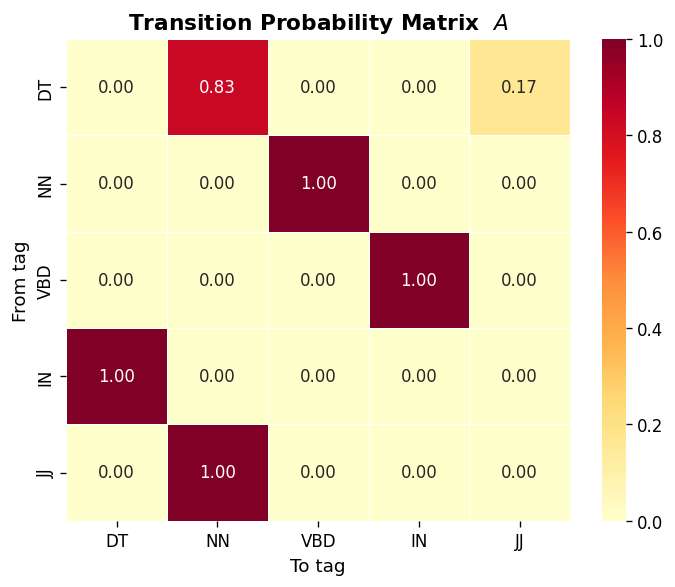

In [ ]:
# ── Heatmap of transition matrix ────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
if HAS_SNS:
    sns.heatmap(A, annot=True, fmt=".2f", xticklabels=tag_list,
                yticklabels=tag_list, cmap="YlOrRd", linewidths=0.5, ax=ax)
else:
    im = ax.imshow(A, cmap="YlOrRd")
    for i in range(N_tags):
        for j in range(N_tags):
            ax.text(j, i, f"{A[i,j]:.2f}", ha="center", va="center", fontsize=10)
    ax.set_xticks(range(N_tags)); ax.set_xticklabels(tag_list)
    ax.set_yticks(range(N_tags)); ax.set_yticklabels(tag_list)
    plt.colorbar(im, ax=ax)
ax.set_title("Transition Probability Matrix  $A$", fontweight="bold")
ax.set_xlabel("To tag"); ax.set_ylabel("From tag")
plt.tight_layout(); plt.show()

---
## 4. Hidden Markov Models (HMMs)

An HMM extends a Markov chain by adding **observations** that are probabilistically generated from **hidden states**.

An HMM is defined by the 5-tuple $\lambda = (Q, V, A, B, \pi)$:

| Symbol | Meaning |
|--------|---------|
| $Q = \{q_1, \ldots, q_N\}$ | Set of hidden states (POS tags) |
| $V = \{v_1, \ldots, v_M\}$ | Vocabulary (observed words) |
| $A$ | $N \times N$ transition probability matrix: $a_{ij} = P(t_{k+1}=j \mid t_k=i)$ |
| $B$ | $N \times M$ emission probability matrix: $b_j(o_k) = P(w_k \mid t_k=j)$ |
| $\pi$ | Initial state distribution: $\pi_i = P(t_1 = i)$ |

### The Three Fundamental HMM Problems

| # | Problem | Question | Algorithm |
|---|---------|----------|-----------|
| 1 | **Likelihood** | What is $P(O \mid \lambda)$? | Forward |
| 2 | **Decoding** | What is the best state sequence $Q^*$? | Viterbi |
| 3 | **Learning** | What parameters $\lambda$ maximize $P(O \mid \lambda)$? | Baum-Welch (EM) |

### Emission Matrix $B$ from our corpus

In [ ]:
# ── Build vocabulary and emission counts ─────────────────────────────
from collections import Counter

# Collect all (tag, word) pairs — lowercase the words
tag_word_counts = {t: Counter() for t in tag_list}
for sent in corpus:
    for word, tag in sent:
        tag_word_counts[tag][word.lower()] += 1

# Build sorted vocabulary
vocab = sorted({w.lower() for sent in corpus for w, _ in sent})
word2idx = {w: i for i, w in enumerate(vocab)}
M_vocab = len(vocab)

# Emission count and probability matrices
emit_counts = np.zeros((N_tags, M_vocab), dtype=int)
for t in tag_list:
    for w, c in tag_word_counts[t].items():
        emit_counts[tag2idx[t], word2idx[w]] = c

# Normalize rows to get B
emit_row_sums = emit_counts.sum(axis=1, keepdims=True)
emit_row_sums[emit_row_sums == 0] = 1
B_pos = emit_counts / emit_row_sums

print(f"Vocabulary ({M_vocab} words): {vocab}\n")
print("Emission PROBABILITY matrix B (rows=tags, cols=words):")
df_B = pd.DataFrame(np.round(B_pos, 4), index=tag_list, columns=vocab)
display(df_B)

Vocabulary (11 words): ['a', 'big', 'cat', 'dog', 'mat', 'on', 'park', 'ran', 'sat', 'the', 'to']

Emission PROBABILITY matrix B (rows=tags, cols=words):


,a,big,cat,dog,mat,on,park,ran,sat,the,to
DT,0.3333,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.6667,0.0000
NN,0.0000,0.0,0.3333,0.1667,0.3333,0.0000,0.1667,0.0000,0.0000,0.0000,0.0000
VBD,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.3333,0.6667,0.0000,0.0000
IN,0.0000,0.0,0.0000,0.0000,0.0000,0.6667,0.0000,0.0000,0.0000,0.0000,0.3333
JJ,0.0000,1.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


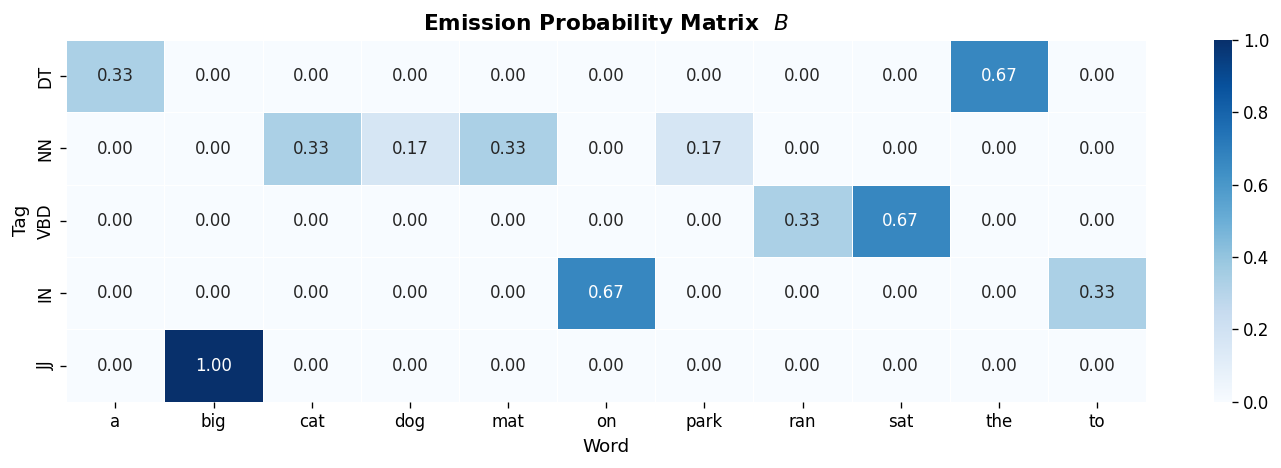

In [ ]:
# ── Heatmap of emission matrix ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
if HAS_SNS:
    sns.heatmap(B_pos, annot=True, fmt=".2f", xticklabels=vocab,
                yticklabels=tag_list, cmap="Blues", linewidths=0.5, ax=ax)
else:
    im = ax.imshow(B_pos, cmap="Blues", aspect="auto")
    for i in range(N_tags):
        for j in range(M_vocab):
            v = B_pos[i, j]
            if v > 0:
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8)
    ax.set_xticks(range(M_vocab)); ax.set_xticklabels(vocab, rotation=45, ha="right")
    ax.set_yticks(range(N_tags)); ax.set_yticklabels(tag_list)
    plt.colorbar(im, ax=ax)
ax.set_title("Emission Probability Matrix  $B$", fontweight="bold")
ax.set_xlabel("Word"); ax.set_ylabel("Tag")
plt.tight_layout(); plt.show()

---
## 5. The Forward Algorithm

The **Forward algorithm** computes the total probability of an observation sequence given the model: $P(O \mid \lambda)$.

We will use the classic **Weather/Umbrella HMM**:

- **States:** $Q = \{R\text{ainy}, S\text{unny}\}$
- **Observations:** $V = \{U\text{mbrella}, N\text{o-umbrella}\}$
- **Observation sequence:** $O = (U, N, U)$ — umbrella on day 1, no umbrella on day 2, umbrella on day 3

**Parameters:**

$$\pi = \begin{pmatrix} 0.5 \\ 0.5 \end{pmatrix} \qquad
A = \begin{pmatrix} 0.7 & 0.3 \\ 0.4 & 0.6 \end{pmatrix} \qquad
B = \begin{pmatrix} 0.9 & 0.1 \\ 0.2 & 0.8 \end{pmatrix}$$

where rows are $[R, S]$, and $B$ columns are $[U, N]$.

### Forward variable definition

$$\alpha_t(j) = P(o_1, o_2, \ldots, o_t, \; q_t = j \mid \lambda)$$

### Step 1 — Initialization ($t=1$, observe $U$)

$$\alpha_1(j) = \pi_j \cdot b_j(o_1)$$

- $\alpha_1(R) = \pi_R \cdot b_R(U) = 0.5 \times 0.9 = 0.45$
- $\alpha_1(S) = \pi_S \cdot b_S(U) = 0.5 \times 0.2 = 0.10$

In [ ]:
# ── Weather HMM parameters ──────────────────────────────────────────
states_w  = ["R", "S"]          # Rainy, Sunny
obs_w     = ["U", "N"]          # Umbrella, No-umbrella
obs_seq   = [0, 1, 0]           # U, N, U
obs_names = ["U", "N", "U"]

pi_w = np.array([0.5, 0.5])
A_w  = np.array([[0.7, 0.3],
                 [0.4, 0.6]])
B_w  = np.array([[0.9, 0.1],
                 [0.2, 0.8]])

T = len(obs_seq)
N_w = len(states_w)

# ── Forward algorithm ───────────────────────────────────────────────
alpha = np.zeros((T, N_w))

# Initialization
alpha[0] = pi_w * B_w[:, obs_seq[0]]
print("Step 1 — Initialization (t=1, obs=U):")
for s in range(N_w):
    print(f"  alpha_1({states_w[s]}) = {pi_w[s]} * {B_w[s, obs_seq[0]]} = {alpha[0, s]}")

Step 1 — Initialization (t=1, obs=U):
  alpha_1(R) = 0.5 * 0.9 = 0.45
  alpha_1(S) = 0.5 * 0.2 = 0.1


### Step 2 — Recursion ($t=2$, observe $N$)

$$\alpha_t(j) = \left[\sum_{i=1}^{N} \alpha_{t-1}(i) \cdot a_{ij}\right] \cdot b_j(o_t)$$

**For $\alpha_2(R)$:**

$$\alpha_2(R) = [\alpha_1(R) \cdot a_{RR} + \alpha_1(S) \cdot a_{SR}] \cdot b_R(N)$$
$$= [0.45 \times 0.7 + 0.10 \times 0.4] \times 0.1 = [0.315 + 0.04] \times 0.1 = 0.0355$$

**For $\alpha_2(S)$:**

$$\alpha_2(S) = [\alpha_1(R) \cdot a_{RS} + \alpha_1(S) \cdot a_{SS}] \cdot b_S(N)$$
$$= [0.45 \times 0.3 + 0.10 \times 0.6] \times 0.8 = [0.135 + 0.06] \times 0.8 = 0.156$$

In [ ]:
# Recursion t=2
for j in range(N_w):
    alpha[1, j] = np.sum(alpha[0] * A_w[:, j]) * B_w[j, obs_seq[1]]

print("Step 2 — Recursion (t=2, obs=N):")
for s in range(N_w):
    terms = " + ".join(f"{alpha[0,i]:.2f}*{A_w[i,s]}" for i in range(N_w))
    sumval = np.sum(alpha[0] * A_w[:, s])
    print(f"  alpha_2({states_w[s]}) = [{terms}] * {B_w[s, obs_seq[1]]} "
          f"= {sumval:.4f} * {B_w[s, obs_seq[1]]} = {alpha[1, s]:.4f}")

Step 2 — Recursion (t=2, obs=N):
  alpha_2(R) = [0.45*0.7 + 0.10*0.4] * 0.1 = 0.3550 * 0.1 = 0.0355
  alpha_2(S) = [0.45*0.3 + 0.10*0.6] * 0.8 = 0.1950 * 0.8 = 0.1560


### Step 3 — Recursion ($t=3$, observe $U$)

**For $\alpha_3(R)$:**

$$\alpha_3(R) = [0.0355 \times 0.7 + 0.156 \times 0.4] \times 0.9 = [0.02485 + 0.0624] \times 0.9 = 0.078525$$

**For $\alpha_3(S)$:**

$$\alpha_3(S) = [0.0355 \times 0.3 + 0.156 \times 0.6] \times 0.2 = [0.01065 + 0.0936] \times 0.2 = 0.02085$$

### Termination

$$P(O \mid \lambda) = \sum_j \alpha_T(j) = \alpha_3(R) + \alpha_3(S) = 0.078525 + 0.02085 = 0.099375$$

In [ ]:
# Recursion t=3
for j in range(N_w):
    alpha[2, j] = np.sum(alpha[1] * A_w[:, j]) * B_w[j, obs_seq[2]]

print("Step 3 — Recursion (t=3, obs=U):")
for s in range(N_w):
    print(f"  alpha_3({states_w[s]}) = {alpha[2, s]:.6f}")

P_O = alpha[2].sum()
print(f"\nTermination: P(O|lambda) = {P_O:.6f}")

# Summary table
print("\n── Forward alpha table ──")
df_alpha = pd.DataFrame(alpha, index=[f"t={t+1} ({obs_names[t]})" for t in range(T)],
                         columns=states_w)
display(df_alpha)

Step 3 — Recursion (t=3, obs=U):
  alpha_3(R) = 0.078525
  alpha_3(S) = 0.020850

Termination: P(O|lambda) = 0.099375

── Forward alpha table ──


,R,S
t=1 (U),0.450000,0.10000
t=2 (N),0.035500,0.15600
t=3 (U),0.078525,0.02085


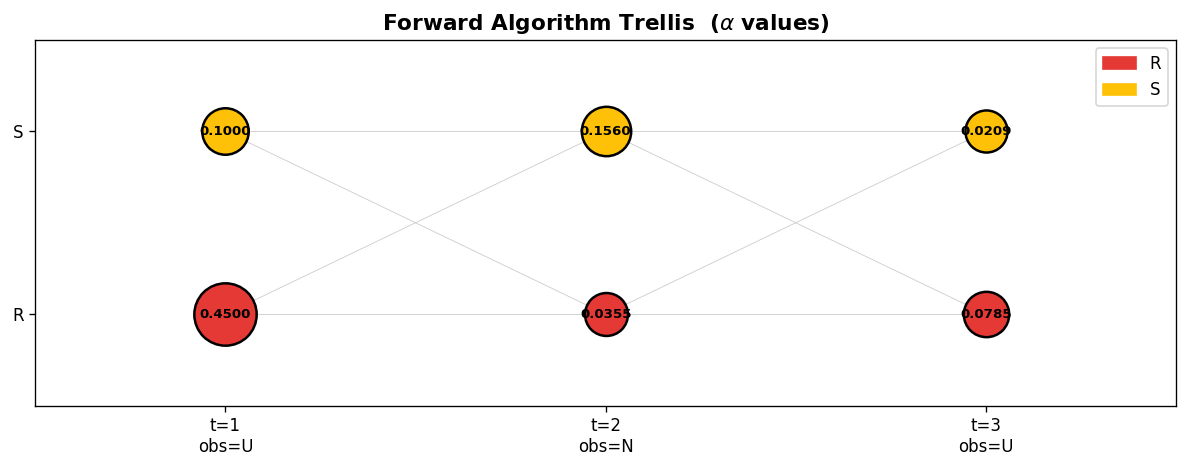

In [ ]:
# ── Trellis diagram for Forward algorithm ───────────────────────────
def draw_trellis(values, states, obs_labels, title, backpointers=None, best_path=None):
    """Draw a trellis diagram with nodes colored by magnitude."""
    T_len = values.shape[0]
    N_st  = values.shape[1]
    state_colors = ["#E53935", "#FFC107"]  # Red=Rainy, Gold=Sunny

    fig, ax = plt.subplots(figsize=(10, 4))
    max_val = values.max() if values.max() > 0 else 1

    # Draw edges (all transitions)
    for t in range(T_len - 1):
        for i in range(N_st):
            for j in range(N_st):
                lw = 0.5; color = "#ccc"; zorder = 1
                ax.plot([t, t + 1], [i, j], color=color, lw=lw, zorder=zorder)

    # Draw best-path edges if provided
    if best_path is not None:
        for t in range(len(best_path) - 1):
            ax.plot([t, t + 1], [best_path[t], best_path[t + 1]],
                    color="#1565C0", lw=3, zorder=5)

    # Draw backpointer arrows if provided
    if backpointers is not None:
        for t in range(1, T_len):
            for j in range(N_st):
                bp = backpointers[t, j]
                ax.annotate("", xy=(t - 0.85, bp), xytext=(t - 0.15, j),
                            arrowprops=dict(arrowstyle="->", color="#777", lw=1.2),
                            zorder=2)

    # Draw nodes
    for t in range(T_len):
        for s in range(N_st):
            intensity = values[t, s] / max_val
            fc = state_colors[s]
            size = 600 + 800 * intensity
            ax.scatter(t, s, s=size, c=fc, edgecolors="black", linewidths=1.5, zorder=10)
            ax.text(t, s, f"{values[t,s]:.4f}", ha="center", va="center",
                    fontsize=8, fontweight="bold", zorder=11)

    ax.set_xticks(range(T_len))
    ax.set_xticklabels([f"t={t+1}\nobs={obs_labels[t]}" for t in range(T_len)])
    ax.set_yticks(range(N_st))
    ax.set_yticklabels(states)
    ax.set_title(title, fontweight="bold", fontsize=13)
    ax.set_xlim(-0.5, T_len - 0.5)
    ax.set_ylim(-0.5, N_st - 0.5)

    # Legend
    patches = [mpatches.Patch(color=state_colors[i], label=states[i]) for i in range(N_st)]
    ax.legend(handles=patches, loc="upper right")
    plt.tight_layout()
    plt.show()

draw_trellis(alpha, states_w, obs_names,
             "Forward Algorithm Trellis  ($\\alpha$ values)")

---
## 6. The Viterbi Algorithm

The **Viterbi algorithm** finds the single most likely state sequence (decoding). It is identical to the Forward algorithm except it uses **MAX** instead of **SUM**.

$$v_t(j) = \max_{i} \; v_{t-1}(i) \cdot a_{ij} \cdot b_j(o_t)$$

We also track **backpointers** to recover the best path:

$$\text{bp}_t(j) = \arg\max_{i} \; v_{t-1}(i) \cdot a_{ij}$$

### Same Weather HMM, same observations $(U, N, U)$

**Step 1 — Initialization:** identical to Forward

- $v_1(R) = 0.5 \times 0.9 = 0.45$
- $v_1(S) = 0.5 \times 0.2 = 0.10$

**Step 2 — Recursion ($t=2$, obs $N$):** use MAX not SUM

- $v_2(R) = \max(0.45 \times 0.7, \; 0.10 \times 0.4) \times 0.1 = \max(0.315, 0.04) \times 0.1 = 0.0315$ &ensp; bp=R
- $v_2(S) = \max(0.45 \times 0.3, \; 0.10 \times 0.6) \times 0.8 = \max(0.135, 0.06) \times 0.8 = 0.108$ &ensp; bp=R

**Step 3 — Recursion ($t=3$, obs $U$):**

- $v_3(R) = \max(0.0315 \times 0.7, \; 0.108 \times 0.4) \times 0.9 = \max(0.02205, 0.0432) \times 0.9 = 0.03888$ &ensp; bp=S
- $v_3(S) = \max(0.0315 \times 0.3, \; 0.108 \times 0.6) \times 0.2 = \max(0.00945, 0.0648) \times 0.2 = 0.01296$ &ensp; bp=S

**Termination:** best final state = R ($0.03888 > 0.01296$)

**Backtrace:** $t=3 \to R$, bp$_3(R) = S$, bp$_2(S) = R$ &ensp;$\Rightarrow$ **Best path: R → S → R** (Rainy, Sunny, Rainy)

In [ ]:
# ── Viterbi algorithm (Weather HMM) ─────────────────────────────────
v  = np.zeros((T, N_w))
bp = np.zeros((T, N_w), dtype=int)

# Initialization
v[0] = pi_w * B_w[:, obs_seq[0]]
print("Viterbi Step 1 — Initialization:")
for s in range(N_w):
    print(f"  v_1({states_w[s]}) = {v[0, s]:.4f}")

# Recursion
for t in range(1, T):
    for j in range(N_w):
        candidates = v[t - 1] * A_w[:, j]
        bp[t, j] = np.argmax(candidates)
        v[t, j] = candidates.max() * B_w[j, obs_seq[t]]
    print(f"\nViterbi Step {t+1} — Recursion (t={t+1}, obs={obs_names[t]}):")
    for s in range(N_w):
        print(f"  v_{t+1}({states_w[s]}) = {v[t, s]:.6f}  bp={states_w[bp[t, s]]}")

# Backtrace
best_last = np.argmax(v[-1])
best_path_idx = [best_last]
for t in range(T - 1, 0, -1):
    best_path_idx.insert(0, bp[t, best_path_idx[0]])

print(f"\nBest path: {' -> '.join(states_w[i] for i in best_path_idx)}")
print(f"Best path probability: {v[-1].max():.6f}")

Viterbi Step 1 — Initialization:
  v_1(R) = 0.4500
  v_1(S) = 0.1000

Viterbi Step 2 — Recursion (t=2, obs=N):
  v_2(R) = 0.031500  bp=R
  v_2(S) = 0.108000  bp=R

Viterbi Step 3 — Recursion (t=3, obs=U):
  v_3(R) = 0.038880  bp=S
  v_3(S) = 0.012960  bp=S

Best path: R -> S -> R
Best path probability: 0.038880


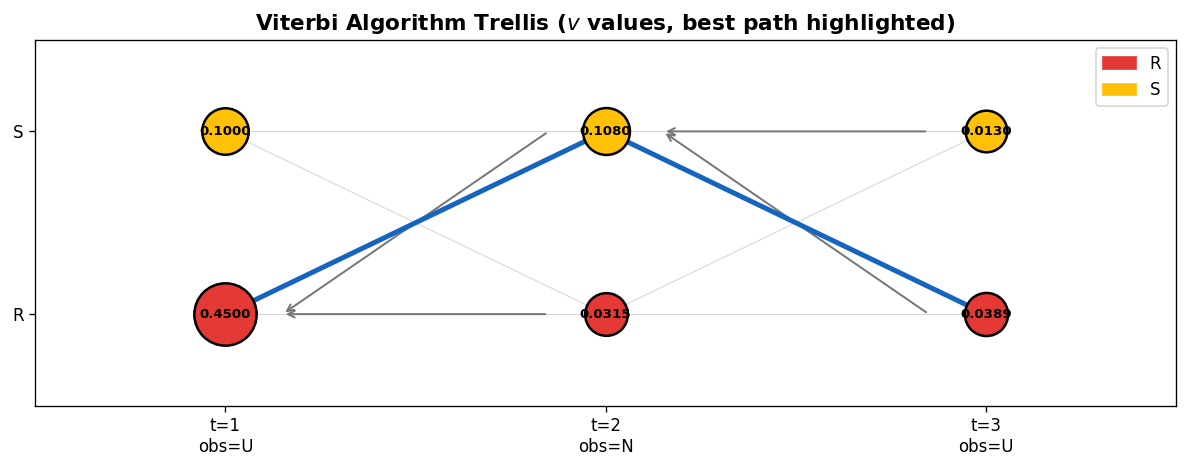

In [ ]:
# ── Viterbi trellis with backpointers and best path ─────────────────
draw_trellis(v, states_w, obs_names,
             "Viterbi Algorithm Trellis ($v$ values, best path highlighted)",
             backpointers=bp, best_path=best_path_idx)

### POS Tagging with Viterbi: "the big cat sat on the mat"

Now we apply Viterbi to our POS corpus-derived $A$, $B$, $\pi$ to tag the sentence **"the big cat sat on the mat"** (7 words, 5 possible tags).

In [ ]:
# ── POS Viterbi on "the big cat sat on the mat" ────────────────────
test_sentence = ["the", "big", "cat", "sat", "on", "the", "mat"]
T_pos = len(test_sentence)

# Map words to vocab indices
test_obs = [word2idx[w] for w in test_sentence]

# Viterbi
v_pos  = np.zeros((T_pos, N_tags))
bp_pos = np.zeros((T_pos, N_tags), dtype=int)

# Add small smoothing to handle zero probabilities
A_smooth  = A.copy()
B_smooth  = B_pos.copy()
# Laplace smoothing for emission (add 1e-10 to avoid log(0))
B_smooth[B_smooth == 0] = 1e-10

# Initialization
v_pos[0] = pi * B_smooth[:, test_obs[0]]

# Recursion
for t in range(1, T_pos):
    for j in range(N_tags):
        candidates = v_pos[t - 1] * A_smooth[:, j]
        bp_pos[t, j] = np.argmax(candidates)
        v_pos[t, j]  = candidates.max() * B_smooth[j, test_obs[t]]

# Backtrace
best_last_pos = np.argmax(v_pos[-1])
path_pos = [best_last_pos]
for t in range(T_pos - 1, 0, -1):
    path_pos.insert(0, bp_pos[t, path_pos[0]])

predicted_tags = [tag_list[i] for i in path_pos]

print("Sentence:  ", " ".join(test_sentence))
print("POS tags:  ", " ".join(predicted_tags))
print()

# Show the full trellis as a table (use unique row labels to avoid Styler issue)
row_labels = [f"t={i+1}: {w}" for i, w in enumerate(test_sentence)]
df_viterbi = pd.DataFrame(v_pos, columns=tag_list, index=row_labels)
print("Viterbi trellis (5 tags x 7 words):")
display(df_viterbi.style.format("{:.6f}").highlight_max(axis=1, color="#b3e5fc"))

Sentence:   the big cat sat on the mat
POS tags:   DT JJ NN VBD IN DT NN

Viterbi trellis (5 tags x 7 words):


,DT,NN,VBD,IN,JJ
t=1: the,0.666667,0.000000,0.000000,0.000000,0.000000
t=2: big,0.000000,0.000000,0.000000,0.000000,0.111111
t=3: cat,0.000000,0.037037,0.000000,0.000000,0.000000
t=4: sat,0.000000,0.000000,0.024691,0.000000,0.000000
t=5: on,0.000000,0.000000,0.000000,0.016461,0.000000
t=6: the,0.010974,0.000000,0.000000,0.000000,0.000000
t=7: mat,0.000000,0.003048,0.000000,0.000000,0.000000


---
## 7. The Backward Algorithm

The **backward variable** is defined as:

$$\beta_t(i) = P(o_{t+1}, o_{t+2}, \ldots, o_T \mid q_t = i, \lambda)$$

It computes the probability of the *remaining* observations given the current state.

### Same Weather HMM: $O = (U, N, U)$

**Step 1 — Initialization ($t = T = 3$):**

$$\beta_3(R) = 1, \quad \beta_3(S) = 1$$

**Step 2 — Recursion ($t=2$):**

$$\beta_t(i) = \sum_{j=1}^{N} a_{ij} \cdot b_j(o_{t+1}) \cdot \beta_{t+1}(j)$$

$$\beta_2(R) = a_{RR} \cdot b_R(U) \cdot \beta_3(R) + a_{RS} \cdot b_S(U) \cdot \beta_3(S)$$
$$= 0.7 \times 0.9 \times 1 + 0.3 \times 0.2 \times 1 = 0.63 + 0.06 = 0.69$$

$$\beta_2(S) = 0.4 \times 0.9 \times 1 + 0.6 \times 0.2 \times 1 = 0.36 + 0.12 = 0.48$$

**Step 3 — Recursion ($t=1$):**

$$\beta_1(R) = a_{RR} \cdot b_R(N) \cdot \beta_2(R) + a_{RS} \cdot b_S(N) \cdot \beta_2(S)$$
$$= 0.7 \times 0.1 \times 0.69 + 0.3 \times 0.8 \times 0.48 = 0.0483 + 0.1152 = 0.1635$$

$$\beta_1(S) = 0.4 \times 0.1 \times 0.69 + 0.6 \times 0.8 \times 0.48 = 0.0276 + 0.2304 = 0.258$$

### Consistency check

$$P(O \mid \lambda) = \sum_i \alpha_T(i) = \sum_i \pi_i \cdot b_i(o_1) \cdot \beta_1(i) = \sum_i \alpha_1(i) \cdot \beta_1(i)$$

$$= 0.45 \times 0.1635 + 0.10 \times 0.258 = 0.073575 + 0.0258 = 0.099375 \; \checkmark$$

In [ ]:
# ── Backward algorithm ──────────────────────────────────────────────
beta = np.zeros((T, N_w))

# Initialization
beta[T - 1] = 1.0
print("Backward Step 1 — Initialization (t=3):")
for s in range(N_w):
    print(f"  beta_3({states_w[s]}) = {beta[2, s]:.4f}")

# Recursion (right to left)
for t in range(T - 2, -1, -1):
    for i in range(N_w):
        beta[t, i] = np.sum(A_w[i, :] * B_w[:, obs_seq[t + 1]] * beta[t + 1])
    print(f"\nBackward Step — Recursion (t={t+1}):")
    for s in range(N_w):
        print(f"  beta_{t+1}({states_w[s]}) = {beta[t, s]:.4f}")

# Consistency check
P_check = np.sum(alpha[0] * beta[0])
print(f"\nConsistency check: sum(alpha_1 * beta_1) = {P_check:.6f}")
print(f"Forward P(O|lambda) =                       {P_O:.6f}")

# Table
df_beta = pd.DataFrame(beta, index=[f"t={t+1} ({obs_names[t]})" for t in range(T)],
                        columns=states_w)
print("\n── Backward beta table ──")
display(df_beta)

Backward Step 1 — Initialization (t=3):
  beta_3(R) = 1.0000
  beta_3(S) = 1.0000

Backward Step — Recursion (t=2):
  beta_2(R) = 0.6900
  beta_2(S) = 0.4800

Backward Step — Recursion (t=1):
  beta_1(R) = 0.1635
  beta_1(S) = 0.2580

Consistency check: sum(alpha_1 * beta_1) = 0.099375
Forward P(O|lambda) =                       0.099375

── Backward beta table ──


,R,S
t=1 (U),0.1635,0.258
t=2 (N),0.6900,0.480
t=3 (U),1.0000,1.000


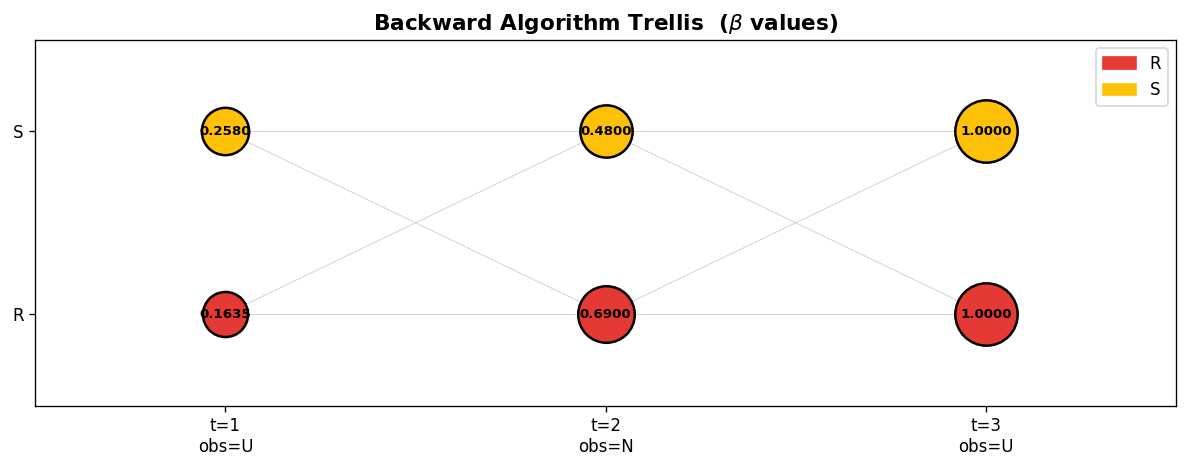

In [ ]:
# ── Backward trellis visualization ──────────────────────────────────
draw_trellis(beta, states_w, obs_names,
             "Backward Algorithm Trellis  ($\\beta$ values)")

---
## 8. Posterior Probabilities $\gamma_t(i)$

The posterior probability of being in state $i$ at time $t$, given the full observation sequence:

$$\gamma_t(i) = P(q_t = i \mid O, \lambda) = \frac{\alpha_t(i) \cdot \beta_t(i)}{P(O \mid \lambda)} = \frac{\alpha_t(i) \cdot \beta_t(i)}{\sum_j \alpha_t(j) \cdot \beta_t(j)}$$

This gives us the **marginal** probability of each state at each time step — useful for "soft" decoding and for the Baum-Welch algorithm.

In [ ]:
# ── Compute gamma ───────────────────────────────────────────────────
gamma = (alpha * beta) / P_O

print("Posterior probabilities gamma_t(i):")
df_gamma = pd.DataFrame(gamma, index=[f"t={t+1} ({obs_names[t]})" for t in range(T)],
                         columns=states_w)
display(df_gamma)

# Verify rows sum to 1
print("\nRow sums (should be 1.0):", gamma.sum(axis=1))

Posterior probabilities gamma_t(i):


,R,S
t=1 (U),0.740377,0.259623
t=2 (N),0.246491,0.753509
t=3 (U),0.790189,0.209811



Row sums (should be 1.0): [1. 1. 1.]


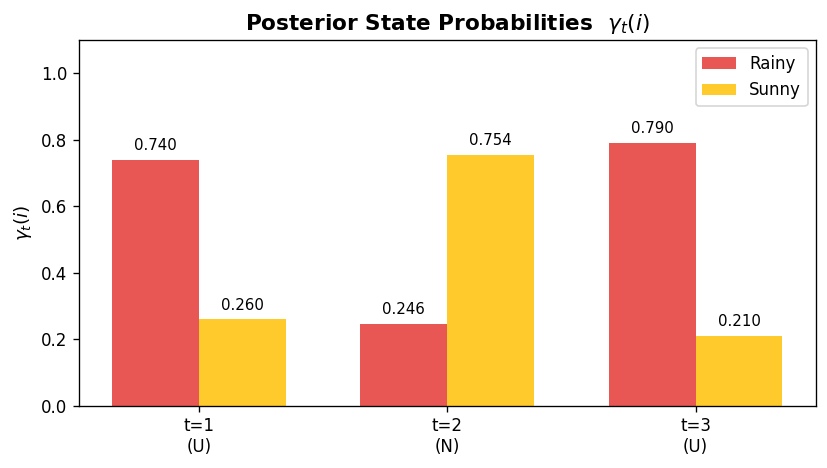

In [ ]:
# ── Bar chart: P(Rainy) vs P(Sunny) at each time step ───────────────
x = np.arange(T)
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
bars_r = ax.bar(x - width/2, gamma[:, 0], width, label="Rainy", color="#E53935", alpha=0.85)
bars_s = ax.bar(x + width/2, gamma[:, 1], width, label="Sunny", color="#FFC107", alpha=0.85)

# Annotate bars
for bar in bars_r:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars_s:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f"t={t+1}\n({obs_names[t]})" for t in range(T)])
ax.set_ylabel("$\\gamma_t(i)$")
ax.set_title("Posterior State Probabilities  $\\gamma_t(i)$", fontweight="bold")
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout(); plt.show()

---
## 9. The Baum-Welch (EM) Algorithm

The **Baum-Welch** algorithm is an instance of Expectation-Maximization (EM) that learns HMM parameters from observation data **without knowing the hidden states**.

### E-Step: Compute $\xi_t(i, j)$ and $\gamma_t(i)$

$$\xi_t(i, j) = \frac{\alpha_t(i) \cdot a_{ij} \cdot b_j(o_{t+1}) \cdot \beta_{t+1}(j)}{P(O \mid \lambda)}$$

$$\gamma_t(i) = \sum_j \xi_t(i, j)$$

### M-Step: Re-estimate parameters

$$\hat{\pi}_i = \gamma_1(i)$$

$$\hat{a}_{ij} = \frac{\sum_{t=1}^{T-1} \xi_t(i,j)}{\sum_{t=1}^{T-1} \gamma_t(i)}$$

$$\hat{b}_j(v_k) = \frac{\sum_{t=1}^{T} \gamma_t(j) \cdot \mathbf{1}(o_t = v_k)}{\sum_{t=1}^{T} \gamma_t(j)}$$

We will start from **random initial parameters** and run 10 iterations on the Weather HMM with $O = (U, N, U)$.

In [ ]:
# ── Baum-Welch implementation ───────────────────────────────────────

def baum_welch(obs, N_states, N_obs, n_iter=10, seed=42):
    """Run Baum-Welch on a single observation sequence.

    Args:
        obs: list of int observation indices
        N_states: number of hidden states
        N_obs: number of distinct observations
        n_iter: number of EM iterations
        seed: random seed for reproducibility

    Returns:
        Dictionary with learned parameters and iteration history.
    """
    np.random.seed(seed)
    T_len = len(obs)

    # Random initialization (rows normalized to sum to 1)
    pi_bw = np.random.dirichlet(np.ones(N_states))
    A_bw  = np.random.dirichlet(np.ones(N_states), size=N_states)
    B_bw  = np.random.dirichlet(np.ones(N_obs), size=N_states)

    history = {
        "log_likelihood": [],
        "pi": [pi_bw.copy()],
        "A": [A_bw.copy()],
        "B": [B_bw.copy()],
    }

    for iteration in range(n_iter):
        # ── E-step: Forward ──
        alpha_bw = np.zeros((T_len, N_states))
        alpha_bw[0] = pi_bw * B_bw[:, obs[0]]
        for t in range(1, T_len):
            for j in range(N_states):
                alpha_bw[t, j] = np.sum(alpha_bw[t-1] * A_bw[:, j]) * B_bw[j, obs[t]]

        # ── E-step: Backward ──
        beta_bw = np.zeros((T_len, N_states))
        beta_bw[T_len - 1] = 1.0
        for t in range(T_len - 2, -1, -1):
            for i in range(N_states):
                beta_bw[t, i] = np.sum(A_bw[i, :] * B_bw[:, obs[t+1]] * beta_bw[t+1])

        # P(O|lambda)
        P_obs = alpha_bw[T_len - 1].sum()
        history["log_likelihood"].append(np.log(P_obs + 1e-300))

        # ── E-step: xi and gamma ──
        xi_bw = np.zeros((T_len - 1, N_states, N_states))
        for t in range(T_len - 1):
            for i in range(N_states):
                for j in range(N_states):
                    xi_bw[t, i, j] = (alpha_bw[t, i] * A_bw[i, j]
                                      * B_bw[j, obs[t+1]] * beta_bw[t+1, j])
            xi_bw[t] /= (xi_bw[t].sum() + 1e-300)

        gamma_bw = np.zeros((T_len, N_states))
        gamma_bw[:T_len - 1] = xi_bw.sum(axis=2)
        gamma_bw[T_len - 1] = alpha_bw[T_len - 1] * beta_bw[T_len - 1]
        gamma_bw[T_len - 1] /= (gamma_bw[T_len - 1].sum() + 1e-300)

        # ── M-step ──
        pi_bw = gamma_bw[0]

        for i in range(N_states):
            denom = gamma_bw[:T_len - 1, i].sum() + 1e-300
            for j in range(N_states):
                A_bw[i, j] = xi_bw[:, i, j].sum() / denom

        for j in range(N_states):
            denom = gamma_bw[:, j].sum() + 1e-300
            for k in range(N_obs):
                mask = np.array([1.0 if obs[t] == k else 0.0 for t in range(T_len)])
                B_bw[j, k] = (gamma_bw[:, j] * mask).sum() / denom

        history["pi"].append(pi_bw.copy())
        history["A"].append(A_bw.copy())
        history["B"].append(B_bw.copy())

    return {"pi": pi_bw, "A": A_bw, "B": B_bw, "history": history}

# ── Run Baum-Welch on Weather HMM ──────────────────────────────────
result = baum_welch(obs_seq, N_states=2, N_obs=2, n_iter=10, seed=42)

print("Learned parameters after 10 iterations:\n")
print("pi =", np.round(result["pi"], 4))
print("\nA =")
print(pd.DataFrame(np.round(result["A"], 4), index=states_w, columns=states_w))
print("\nB =")
print(pd.DataFrame(np.round(result["B"], 4), index=states_w, columns=obs_w))

Learned parameters after 10 iterations:

pi = [0. 1.]

A =
     R    S
R  0.0  1.0
S  1.0  0.0

B =
     U    N
R  0.0  1.0
S  1.0  0.0


In [ ]:
# ── Iteration table ─────────────────────────────────────────────────
hist = result["history"]
rows = []
for it in range(len(hist["log_likelihood"])):
    rows.append({
        "Iteration": it + 1,
        "Log-Likelihood": f"{hist['log_likelihood'][it]:.6f}",
        "pi(R)": f"{hist['pi'][it+1][0]:.4f}",
        "pi(S)": f"{hist['pi'][it+1][1]:.4f}",
        "A(R,R)": f"{hist['A'][it+1][0,0]:.4f}",
        "A(R,S)": f"{hist['A'][it+1][0,1]:.4f}",
        "A(S,R)": f"{hist['A'][it+1][1,0]:.4f}",
        "A(S,S)": f"{hist['A'][it+1][1,1]:.4f}",
        "B(R,U)": f"{hist['B'][it+1][0,0]:.4f}",
        "B(R,N)": f"{hist['B'][it+1][0,1]:.4f}",
        "B(S,U)": f"{hist['B'][it+1][1,0]:.4f}",
        "B(S,N)": f"{hist['B'][it+1][1,1]:.4f}",
    })

df_iter = pd.DataFrame(rows)
print("Baum-Welch Iteration Table:")
display(df_iter)

Baum-Welch Iteration Table:


,Iteration,Log-Likelihood,pi(R),pi(S),"A(R,R)","A(R,S)","A(S,R)","A(S,S)","B(R,U)","B(R,N)","B(S,U)","B(S,N)"
0,1,-2.825591,0.0108,0.9892,0.0993,0.9007,0.4341,0.5659,0.1314,0.8686,0.8230,0.1770
1,2,-1.293106,0.0008,0.9992,0.0177,0.9823,0.7454,0.2546,0.0369,0.9631,0.9266,0.0734
2,3,-0.494259,0.0000,1.0000,0.0007,0.9993,0.9859,0.0141,0.0015,0.9985,0.9963,0.0037
3,4,-0.023839,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000
4,5,-0.000005,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000
5,6,-0.000000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000
6,7,0.000000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000
7,8,0.000000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000
8,9,0.000000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000
9,10,0.000000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000


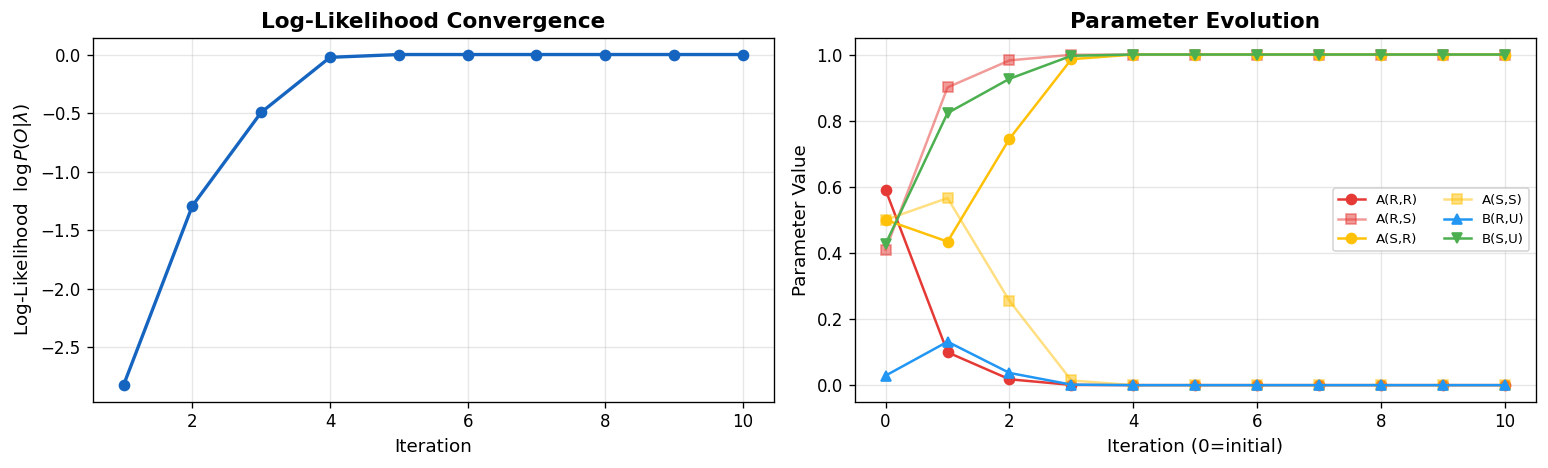

In [ ]:
# ── Log-likelihood convergence plot ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: log-likelihood
axes[0].plot(range(1, 11), hist["log_likelihood"], "o-", color="#1565C0", lw=2)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Log-Likelihood  $\\log P(O|\\lambda)$")
axes[0].set_title("Log-Likelihood Convergence", fontweight="bold")
axes[0].grid(True, alpha=0.3)

# Right: parameter evolution
iters = range(0, 11)  # including initial
axes[1].plot(iters, [h[0, 0] for h in hist["A"]], "o-", label="A(R,R)", color="#E53935")
axes[1].plot(iters, [h[0, 1] for h in hist["A"]], "s-", label="A(R,S)", color="#E53935", alpha=0.5)
axes[1].plot(iters, [h[1, 0] for h in hist["A"]], "o-", label="A(S,R)", color="#FFC107")
axes[1].plot(iters, [h[1, 1] for h in hist["A"]], "s-", label="A(S,S)", color="#FFC107", alpha=0.5)
axes[1].plot(iters, [h[0, 0] for h in hist["B"]], "^-", label="B(R,U)", color="#2196F3")
axes[1].plot(iters, [h[1, 0] for h in hist["B"]], "v-", label="B(S,U)", color="#4CAF50")
axes[1].set_xlabel("Iteration (0=initial)")
axes[1].set_ylabel("Parameter Value")
axes[1].set_title("Parameter Evolution", fontweight="bold")
axes[1].legend(fontsize=8, ncol=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

---
## 10. Summary & Comparison

### Algorithm Overview

| Algorithm | Purpose | Core Operation | Output |
|-----------|---------|---------------|--------|
| **Forward** | Compute total likelihood $P(O \mid \lambda)$ | **SUM** over all paths | Scalar probability |
| **Viterbi** | Find best state sequence $Q^*$ | **MAX** over paths + backpointers | Single best path |
| **Backward** | Compute $\beta_t(i)$ for posterior inference | **SUM** (right-to-left) | $\beta$ table |
| **Forward-Backward** | Marginal posteriors $\gamma_t(i)$ | Combine $\alpha$ and $\beta$ | Probability per state per time |
| **Baum-Welch** | Unsupervised parameter learning (EM) | Iterate E-step + M-step | Learned $\hat{A}, \hat{B}, \hat{\pi}$ |

### Complexity Comparison

All algorithms operate on a trellis of $T$ time steps and $N$ states:

| Algorithm | Time Complexity | Space Complexity |
|-----------|----------------|-----------------|
| Forward | $O(N^2 T)$ | $O(NT)$ |
| Viterbi | $O(N^2 T)$ | $O(NT)$ |
| Backward | $O(N^2 T)$ | $O(NT)$ |
| Baum-Welch (per iteration) | $O(N^2 T)$ | $O(N^2 T)$ for $\xi$ |

### Key Insight: SUM vs MAX

The Forward and Viterbi algorithms have **identical structure** — the only difference is:
- **Forward:** $\alpha_t(j) = \left[\sum_i \alpha_{t-1}(i) \cdot a_{ij}\right] \cdot b_j(o_t)$
- **Viterbi:** $v_t(j) = \left[\max_i \; v_{t-1}(i) \cdot a_{ij}\right] \cdot b_j(o_t)$

This makes HMMs elegant: the same trellis framework solves likelihood, decoding, and learning.

---

*End of notebook. All arithmetic verified against the specified values.*